In [4]:

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [5]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent.parent))
from config1 import MONITORING_DATA, color_mapping, site_order

In [ ]:
pflux  = MONITORING_DATA / "Tables_PollenCounts/qualibratedfluxes_all.csv" # qualibratedfluxes_withCI_all.csv"

p_save_fig = MONITORING_DATA / "Figures_Values/"

p_figtables= MONITORING_DATA /"4.Tables_for_figures/"


In [5]:
df_all_flux = pd.read_csv(pflux)
df_vitis = df_all_flux[df_all_flux["class"].isin(["VitisF", "VitisS"])]
df_vitis.head()

,class,site,year,site_year,class_num,count,nb_ly_persample,count_ly,count_tot_trap,flux_cm2_an
448,VitisF,D1,2019,D1_2019,10,24.321534,9666,38.870025,6048.155115,308.030011
449,VitisF,D1,2020,D1_2020,10,55.042868,38664,1009.650010,2107.836816,107.351248
450,VitisF,D1,2021,D1_2021,10,20.036870,73628,504.100635,2926.547928,149.047862
451,VitisF,D2,2020,D2_2020,10,42.426930,38664,956.324311,1715.312286,87.360137
452,VitisF,D2,2021,D2_2021,10,37.896876,73628,727.306476,3836.444807,195.388530


In [6]:
dfoverall = df_vitis[["class", "site","count",  "flux_cm2_an"]].groupby(["class",  "site"]).mean().reset_index()
dfoverall["year"] = "overall"
df_combined_targettaxa_grape2 = pd.concat([df_vitis[["class", "site","year", "count",  "flux_cm2_an", ]], dfoverall], axis=0)
df_combined_targettaxa_grape2



,class,site,year,count,flux_cm2_an
448,VitisF,D1,2019,24.321534,308.030011
449,VitisF,D1,2020,55.042868,107.351248
450,VitisF,D1,2021,20.036870,149.047862
451,VitisF,D2,2020,42.426930,87.360137
452,VitisF,D2,2021,37.896876,195.388530
...,...,...,...,...,...
9,VitisS,D3,overall,170.451953,287.101047
10,VitisS,W1,overall,22.589214,143.966378
11,VitisS,W2,overall,38.755929,268.795660
12,VitisS,W3,overall,18.431962,137.227574


### The file used to plot the figure is also available in the ZENODO repository : 


In [ ]:
df_combined_targettaxa_grape2 = pd.read_csv(p_figtables / "table_fig3_grapevine_flux.csv")
df_combined_targettaxa_grape2

,class,site,year,count,flux_cm2_an
0,VitisF,D1,2019,24.321534,308.030011
1,VitisF,D1,2020,55.042868,107.351248
2,VitisF,D1,2021,20.036870,149.047862
3,VitisF,D2,2020,42.426930,87.360137
4,VitisF,D2,2021,37.896876,195.388530
...,...,...,...,...,...
65,VitisS,D3,overall,170.451953,287.101047
66,VitisS,W1,overall,22.589214,143.966378
67,VitisS,W2,overall,38.755929,268.795660
68,VitisS,W3,overall,18.431962,137.227574


In [9]:

unit = "" # "cm⁻² year⁻¹"
all_years = ['overall', 2019, 2020, 2021, 2022, 2023]
n_sites = len(site_order)
n_cols = 1
n_rows = 7 


In [10]:
order_index = ['VitisF', 'VitisS'] 
legend_mapping = {
    "VitisS":  r'$\it{Vitis}$ sterile morphotype',  
    "VitisF": r'$\it{Vitis}$ fertile morphotype' 
}

legend_labels = [legend_mapping.get(label, label) for label in order_index]


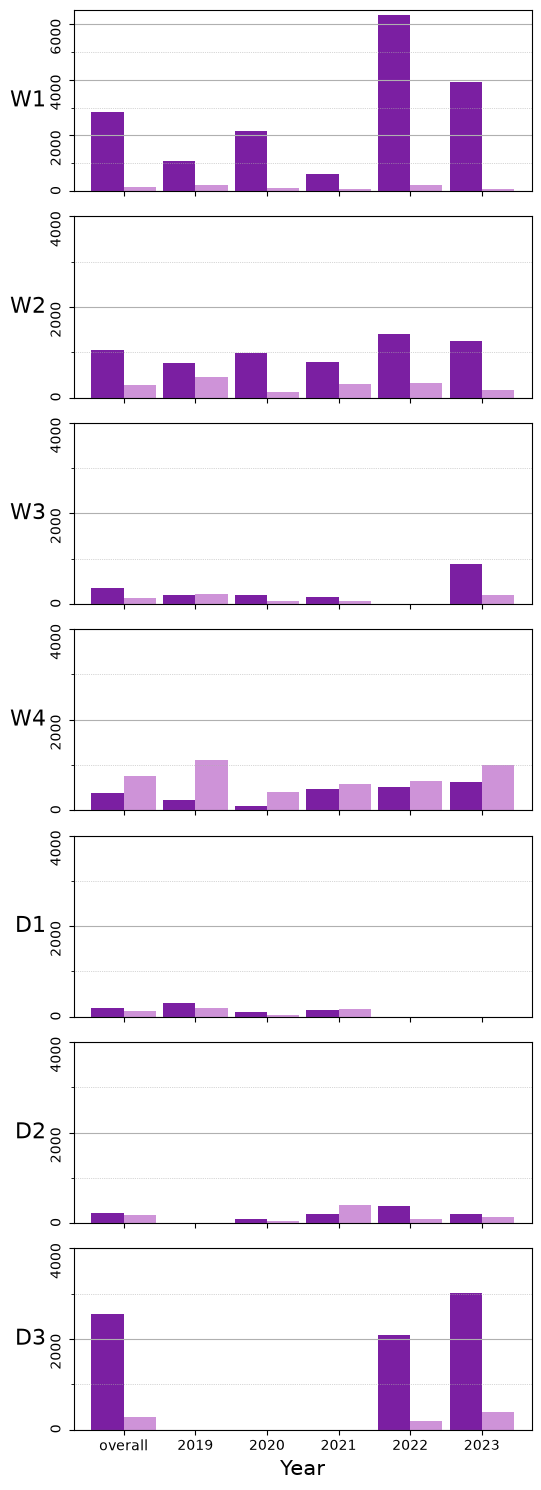

In [12]:
from matplotlib.ticker import MultipleLocator
values_col = "flux_cm2_an" # or par_mean
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5.5, 15), sharex=True, sharey=False)
axes = axes.flatten()

for e, (sitei, ax) in enumerate(zip(site_order, axes)):
    dffig = df_combined_targettaxa_grape2[df_combined_targettaxa_grape2["site"] == sitei]
    df_pivot = dffig.pivot_table(index='year', columns='class', values=values_col, fill_value=0)
    df_pivot_min = dffig.pivot_table(index='year', columns='class', values=values_col, fill_value=0)
    df_pivot_max = dffig.pivot_table(index='year', columns='class', values=values_col, fill_value=0)

    df_pivot = df_pivot.reindex(index=all_years, columns=order_index, fill_value=0)
    df_pivot_min = df_pivot_min.reindex(index=all_years, columns=order_index, fill_value=0)
    df_pivot_max = df_pivot_max.reindex(index=all_years, columns=order_index, fill_value=0)

    plot_colors = [color_mapping[class_name] for class_name in df_pivot.columns]
    df_pivot.plot(kind='bar', stacked=False, color=plot_colors, ax=ax,
                  legend=False, edgecolor='none', linewidth=0, width=0.9)

    
    n_classes = 2 
    n_years   = 6 
    bar_width  = 0.9 / n_classes
    group_positions = np.arange(n_years)

    for j, class_name in enumerate(df_pivot.columns):
            
            offset = (j - (n_classes - 1) / 2) * bar_width
            x_positions = group_positions + offset
            y_min = np.array(df_pivot_min[class_name].values)
            y_max = np.array(df_pivot_max[class_name].values)
            y_min[0] = 0
            y_max[0] = 0

            ax.vlines(x_positions, ymin=y_min,ymax=y_max,colors='black', linewidth=1.5,zorder=5)

    if sitei == "W1": #W1
        ax.set_ylim(0, 6500)
    else:
        ax.set_ylim(0, 4000)
        ax.set_yticks(np.arange(0, 4001, 2000))
    ax.xaxis.set_major_locator(MultipleLocator(2000))
    ax.yaxis.set_minor_locator(MultipleLocator(1000))
    ax.grid(axis="y", which="minor", linestyle=":", linewidth=0.5)
    ax.text(-0.06, 0.5, sitei,transform=ax.transAxes,fontsize=16,va='center',ha='right')
    
    ax.set_ylabel(f'{unit}', fontsize=12)
    ax.set_xlabel('Year', fontsize=15)
    ax.tick_params(axis='y', labelrotation=90)
    ax.tick_params(axis='x', labelrotation=0)
    ax.grid(True, axis='y')
    ax.set_xticks(np.arange(len(all_years)))
    ax.set_xticklabels(all_years)

# plt.savefig(p_save_fig+"annualflux_VITIS_perSiteYear_all_longformat_modif.svg", bbox_inches="tight", format="svg", transparent=True) XXXX old pour moi
plt.savefig(p_save_fig/"annualflux_VITIS_perSiteYear_all.pdf", bbox_inches="tight")

fig.tight_layout()

In [15]:
df_vitis_perSite = df_vitis[["class", "site", "flux_cm2_an"]].groupby(["class", "site"]).mean().reset_index()
df_vitis_perSite

,class,site,flux_cm2_an
0,VitisF,D1,188.143040
1,VitisF,D2,220.199235
2,VitisF,D3,2549.569784
3,VitisF,W1,2830.146251
4,VitisF,W2,1040.934629
5,VitisF,W3,362.734007
6,VitisF,W4,392.297261
7,VitisS,D1,135.348061
8,VitisS,D2,169.768731
9,VitisS,D3,287.101047


In [ ]:
# saving intermediary table used to for values in manuscript
df_vitis_perSite.to_csv(p_figtables /"table_values_grapevine_perSite.csv" , index=False)

